# 🚚 Late Delivery Risk Scoring – Data Understanding & Cleaning
### Olist Brazilian E-Commerce Dataset · Capstone Project · IBT x GGateway 2025

This notebook covers **Week 8** deliverables of the capstone plan:
- **Step 1 – Understand the Data:** Build a complete data dictionary for every table and every column.
- **Step 2 – Clean the Data:** Fix data types, handle missing values, remove duplicates, identify and treat outliers, and merge all tables into one analysis-ready master DataFrame.

All decisions are documented with a *why* so this notebook tells a clean portfolio story.

## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# ── Plotting style ────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":        120,
    "figure.facecolor":  "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "DejaVu Sans",
})
sns.set_palette("Blues_r")

print("Libraries loaded ✓")

Libraries loaded ✓


## 2. Load Raw Data

We load every CSV individually, then later merge them into a single master DataFrame.
The three geolocation files are split parts of the same table and are concatenated immediately.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# ── File paths ────────────────────────────────────────────────
DATA_PATH = "data/"          # adjust if running locally; the uploads are at the path below
UPLOAD    = "/content/drive/MyDrive/Colab Notebooks/Olist/"

# ── Customers ─────────────────────────────────────────────────
customers = pd.read_csv(UPLOAD + "olist_customers_dataset.csv")

# ── Orders ────────────────────────────────────────────────────
orders = pd.read_csv(UPLOAD + "olist_orders_dataset.csv")

# ── Order Items ───────────────────────────────────────────────
order_items = pd.read_csv(UPLOAD + "olist_order_items_dataset.csv")

# ── Payments ──────────────────────────────────────────────────
payments = pd.read_csv(UPLOAD + "olist_order_payments_dataset.csv")

# ── Reviews ───────────────────────────────────────────────────
reviews = pd.read_csv(UPLOAD + "olist_order_reviews_dataset.csv")

# ── Products ──────────────────────────────────────────────────
products = pd.read_csv(UPLOAD + "olist_products_dataset.csv")

# ── Sellers ───────────────────────────────────────────────────
sellers = pd.read_csv(UPLOAD + "olist_sellers_dataset.csv")

# ── Category name translation ─────────────────────────────────
category_translation = pd.read_csv(UPLOAD + "product_category_name_translation.csv")

# ── Geolocation (3 split files → concatenate into one) ────────
geo1 = pd.read_csv(UPLOAD + "olist_geolocation_dataset_1.csv")
geo2 = pd.read_csv(UPLOAD + "olist_geolocation_dataset_2.csv")
geo3 = pd.read_csv(UPLOAD + "olist_geolocation_dataset_3.csv")
geolocation = pd.concat([geo1, geo2, geo3], ignore_index=True)

# ── Quick shape summary ───────────────────────────────────────
datasets = {
    "customers":           customers,
    "orders":              orders,
    "order_items":         order_items,
    "payments":            payments,
    "reviews":             reviews,
    "products":            products,
    "sellers":             sellers,
    "category_translation":category_translation,
    "geolocation":         geolocation,
}

print(f"{'Table':<25} {'Rows':>8} {'Cols':>6}")
print("-" * 42)
for name, df in datasets.items():
    print(f"{name:<25} {df.shape[0]:>8,} {df.shape[1]:>6}")

Table                         Rows   Cols
------------------------------------------
customers                   99,441      5
orders                      99,441      8
order_items                112,650      7
payments                   103,886      5
reviews                     99,224      7
products                    32,951      9
sellers                      3,095      4
category_translation            71      2
geolocation               1,000,163      5


## 3. Data Dictionary (Step 1 – Understand the Data)

A data dictionary is the **first thing any analyst should build**. It forces you to think about
what each column actually means before you touch any cleaning or modelling code.
For each table we document: column name, business meaning, data type, and any notes
about units, categories, or known issues.

The schema diagram shows how tables connect:
- `olist_orders_dataset` is the **central hub** — it links to customers (via `customer_id`),
  payments and reviews (via `order_id`), and to order items (via `order_id`).
- `olist_order_items_dataset` is the **bridge** — each row is one item in one order,
  linking to both `products` (via `product_id`) and `sellers` (via `seller_id`).
- `olist_geolocation_dataset` connects to both customers and sellers via `zip_code_prefix`.

In [6]:
# ── Data dictionary helper ───────────────────────────────────
def data_dict(df, entries):
    """
    Display a formatted data dictionary.
    entries: list of (col, meaning, dtype_override, notes)
    """
    rows = []
    for col, meaning, dtype_override, notes in entries:
        actual_dtype = str(df[col].dtype) if col in df.columns else "—"
        rows.append({
            "Column":    col,
            "Meaning":   meaning,
            "Raw dtype": actual_dtype,
            "Cast to":   dtype_override,
            "Notes":     notes,
        })
    return pd.DataFrame(rows).set_index("Column")

# ── 3.1 Customers ────────────────────────────────────────────
print("=" * 70)
print("TABLE: olist_customers_dataset  (99,441 rows)")
print("One row = one customer ID (linked to one order).")
print("=" * 70)

display(data_dict(customers, [
    ("customer_id",              "Unique key linking customer to an order",   "str (keep)",    "Anonymised hash. 1-to-1 with orders."),
    ("customer_unique_id",       "True unique customer identity",              "str (keep)",    "Same person may have multiple customer_id values across orders."),
    ("customer_zip_code_prefix", "First 5 digits of customer postal code",    "str (coerce)",  "Join key to geolocation. Currently int64 — must be stored as zero-padded string."),
    ("customer_city",            "City name of the customer",                  "str (keep)",    "Free text; may have capitalisation inconsistencies."),
    ("customer_state",           "Brazilian state abbreviation (2-letter)",    "str (keep)",    "27 unique values (26 states + DF)."),
]))

TABLE: olist_customers_dataset  (99,441 rows)
One row = one customer ID (linked to one order).


,Meaning,Raw dtype,Cast to,Notes
Column,,,,
customer_id,Unique key linking customer to an order,object,str (keep),Anonymised hash. 1-to-1 with orders.
customer_unique_id,True unique customer identity,object,str (keep),Same person may have multiple customer_id valu...
customer_zip_code_prefix,First 5 digits of customer postal code,int64,str (coerce),Join key to geolocation. Currently int64 — mus...
customer_city,City name of the customer,object,str (keep),Free text; may have capitalisation inconsisten...
customer_state,Brazilian state abbreviation (2-letter),object,str (keep),27 unique values (26 states + DF).


In [7]:
# ── 3.2 Orders ───────────────────────────────────────────────
print("=" * 70)
print("TABLE: olist_orders_dataset  (99,441 rows)")
print("One row = one customer order. Central fact table of the schema.")
print("=" * 70)

display(data_dict(orders, [
    ("order_id",                      "Unique order identifier",                      "str (keep)",      "Primary key."),
    ("customer_id",                   "Links to customers table",                     "str (keep)",      "Foreign key."),
    ("order_status",                  "Current fulfillment status of the order",      "str (keep)",      "8 categories: delivered, shipped, canceled, unavailable, invoiced, processing, created, approved."),
    ("order_purchase_timestamp",      "When the customer placed the order",           "datetime",        "No missing values. Parse to datetime."),
    ("order_approved_at",             "When payment was approved",                    "datetime",        "160 nulls — order may not have been approved (e.g., canceled)."),
    ("order_delivered_carrier_date",  "When the seller handed off to the carrier",    "datetime",        "1,783 nulls — not yet shipped or canceled."),
    ("order_delivered_customer_date", "When the customer actually received the order","datetime",        "2,965 nulls — key target column. Missing = not yet delivered."),
    ("order_estimated_delivery_date", "Promised delivery date shown to the customer", "datetime",        "No missing values. Used to compute delay gap."),
]))

TABLE: olist_orders_dataset  (99,441 rows)
One row = one customer order. Central fact table of the schema.


,Meaning,Raw dtype,Cast to,Notes
Column,,,,
order_id,Unique order identifier,object,str (keep),Primary key.
customer_id,Links to customers table,object,str (keep),Foreign key.
order_status,Current fulfillment status of the order,object,str (keep),"8 categories: delivered, shipped, canceled, un..."
order_purchase_timestamp,When the customer placed the order,object,datetime,No missing values. Parse to datetime.
order_approved_at,When payment was approved,object,datetime,160 nulls — order may not have been approved (...
order_delivered_carrier_date,When the seller handed off to the carrier,object,datetime,"1,783 nulls — not yet shipped or canceled."
order_delivered_customer_date,When the customer actually received the order,object,datetime,"2,965 nulls — key target column. Missing = not..."
order_estimated_delivery_date,Promised delivery date shown to the customer,object,datetime,No missing values. Used to compute delay gap.


In [8]:
# ── 3.3 Order Items ──────────────────────────────────────────
print("=" * 70)
print("TABLE: olist_order_items_dataset  (112,650 rows)")
print("One row = one item within one order. An order can have multiple items.")
print("=" * 70)

display(data_dict(order_items, [
    ("order_id",            "Links to orders table",                      "str (keep)",  "Foreign key. Multiple rows per order_id are normal."),
    ("order_item_id",       "Item sequence number within the order (1,2,3…)", "int (keep)", "Not unique globally; resets per order."),
    ("product_id",          "Links to products table",                    "str (keep)",  "Foreign key."),
    ("seller_id",           "Links to sellers table",                     "str (keep)",  "Foreign key."),
    ("shipping_limit_date", "Deadline for the seller to hand off to carrier", "datetime", "No nulls. Must be ≤ actual carrier pickup date ideally."),
    ("price",               "Product sale price in Brazilian Reais (BRL)", "float (keep)", "No nulls. Range: 0.85–6,735 BRL. High values to be reviewed for outliers."),
    ("freight_value",       "Shipping cost in BRL",                       "float (keep)", "No nulls. Range: 0–409.68 BRL. Zero freight may be free shipping."),
]))

TABLE: olist_order_items_dataset  (112,650 rows)
One row = one item within one order. An order can have multiple items.


,Meaning,Raw dtype,Cast to,Notes
Column,,,,
order_id,Links to orders table,object,str (keep),Foreign key. Multiple rows per order_id are no...
order_item_id,"Item sequence number within the order (1,2,3…)",int64,int (keep),Not unique globally; resets per order.
product_id,Links to products table,object,str (keep),Foreign key.
seller_id,Links to sellers table,object,str (keep),Foreign key.
shipping_limit_date,Deadline for the seller to hand off to carrier,object,datetime,No nulls. Must be ≤ actual carrier pickup date...
price,Product sale price in Brazilian Reais (BRL),float64,float (keep),"No nulls. Range: 0.85–6,735 BRL. High values t..."
freight_value,Shipping cost in BRL,float64,float (keep),No nulls. Range: 0–409.68 BRL. Zero freight ma...


In [9]:
# ── 3.4 Payments ────────────────────────────────────────────
print("=" * 70)
print("TABLE: olist_order_payments_dataset  (103,886 rows)")
print("One row = one payment transaction. Orders can split across payment types.")
print("=" * 70)

display(data_dict(payments, [
    ("order_id",              "Links to orders table",                    "str (keep)",  "Foreign key. Multiple rows per order if payment was split."),
    ("payment_sequential",    "Payment sequence number within the order", "int (keep)",  "Starts at 1. If an order uses both credit card and voucher, there will be 2 rows."),
    ("payment_type",          "Method of payment",                        "str (keep)",  "Categories: credit_card, boleto, voucher, debit_card, not_defined."),
    ("payment_installments",  "Number of installments chosen",            "int (keep)",  "0 = not applicable. Up to 24 installments observed."),
    ("payment_value",         "Amount paid in this transaction (BRL)",    "float (keep)","No nulls."),
]))

TABLE: olist_order_payments_dataset  (103,886 rows)
One row = one payment transaction. Orders can split across payment types.


,Meaning,Raw dtype,Cast to,Notes
Column,,,,
order_id,Links to orders table,object,str (keep),Foreign key. Multiple rows per order if paymen...
payment_sequential,Payment sequence number within the order,int64,int (keep),Starts at 1. If an order uses both credit card...
payment_type,Method of payment,object,str (keep),"Categories: credit_card, boleto, voucher, debi..."
payment_installments,Number of installments chosen,int64,int (keep),0 = not applicable. Up to 24 installments obse...
payment_value,Amount paid in this transaction (BRL),float64,float (keep),No nulls.


In [10]:
# ── 3.5 Reviews ──────────────────────────────────────────────
print("=" * 70)
print("TABLE: olist_order_reviews_dataset  (104,719 rows)")
print("One row = one customer review for one order.")
print("=" * 70)

display(data_dict(reviews, [
    ("review_id",              "Unique review identifier",                     "str (keep)",  "Primary key."),
    ("order_id",               "Links to orders table",                        "str (keep)",  "Foreign key."),
    ("review_score",           "Star rating given by the customer (1–5)",      "int (keep)",  "No nulls. Ordinal scale."),
    ("review_comment_title",   "Short title of the review text",               "str / NaN",   "~58% missing — customers rarely fill this in."),
    ("review_comment_message", "Full review text from the customer",           "str / NaN",   "~42% missing — optional field."),
    ("review_creation_date",   "When the review request was sent to customer", "datetime",    "No nulls."),
    ("review_answer_timestamp","When the customer submitted the review",       "datetime",    "No nulls."),
]))

TABLE: olist_order_reviews_dataset  (104,719 rows)
One row = one customer review for one order.


,Meaning,Raw dtype,Cast to,Notes
Column,,,,
review_id,Unique review identifier,object,str (keep),Primary key.
order_id,Links to orders table,object,str (keep),Foreign key.
review_score,Star rating given by the customer (1–5),int64,int (keep),No nulls. Ordinal scale.
review_comment_title,Short title of the review text,object,str / NaN,~58% missing — customers rarely fill this in.
review_comment_message,Full review text from the customer,object,str / NaN,~42% missing — optional field.
review_creation_date,When the review request was sent to customer,object,datetime,No nulls.
review_answer_timestamp,When the customer submitted the review,object,datetime,No nulls.


In [11]:
# ── 3.6 Products ─────────────────────────────────────────────
print("=" * 70)
print("TABLE: olist_products_dataset  (32,951 rows)")
print("One row = one unique product SKU.")
print("=" * 70)

display(data_dict(products, [
    ("product_id",                  "Unique product identifier",                     "str (keep)",  "Primary key."),
    ("product_category_name",       "Product category in Portuguese",                "str / NaN",   "610 nulls (~1.9%). Will be joined to English translation."),
    ("product_name_lenght",         "Character length of the product name",          "float",       "Note: intentional typo in source ('lenght'). 610 nulls matching category nulls."),
    ("product_description_lenght",  "Character length of the product description",   "float",       "610 nulls."),
    ("product_photos_qty",          "Number of product photos on the listing",       "float",       "610 nulls."),
    ("product_weight_g",            "Product weight in grams",                       "float",       "2 nulls. Will impute with median."),
    ("product_length_cm",           "Package length in centimetres",                 "float",       "2 nulls. Will impute with median."),
    ("product_height_cm",           "Package height in centimetres",                 "float",       "2 nulls. Will impute with median."),
    ("product_width_cm",            "Package width in centimetres",                  "float",       "2 nulls. Will impute with median."),
]))

TABLE: olist_products_dataset  (32,951 rows)
One row = one unique product SKU.


,Meaning,Raw dtype,Cast to,Notes
Column,,,,
product_id,Unique product identifier,object,str (keep),Primary key.
product_category_name,Product category in Portuguese,object,str / NaN,610 nulls (~1.9%). Will be joined to English t...
product_name_lenght,Character length of the product name,float64,float,Note: intentional typo in source ('lenght'). 6...
product_description_lenght,Character length of the product description,float64,float,610 nulls.
product_photos_qty,Number of product photos on the listing,float64,float,610 nulls.
product_weight_g,Product weight in grams,float64,float,2 nulls. Will impute with median.
product_length_cm,Package length in centimetres,float64,float,2 nulls. Will impute with median.
product_height_cm,Package height in centimetres,float64,float,2 nulls. Will impute with median.
product_width_cm,Package width in centimetres,float64,float,2 nulls. Will impute with median.


In [12]:
# ── 3.7 Sellers ──────────────────────────────────────────────
print("=" * 70)
print("TABLE: olist_sellers_dataset  (3,095 rows)")
print("One row = one registered seller on the platform.")
print("=" * 70)

display(data_dict(sellers, [
    ("seller_id",             "Unique seller identifier",                       "str (keep)",  "Primary key."),
    ("seller_zip_code_prefix","First 5 digits of seller postal code",           "str (coerce)","Join key to geolocation. Same issue as customers: stored as int, should be zero-padded string."),
    ("seller_city",           "City where the seller is located",               "str (keep)",  "Free text; some inconsistencies expected."),
    ("seller_state",          "Brazilian state abbreviation (2-letter)",        "str (keep)",  ""),
]))

TABLE: olist_sellers_dataset  (3,095 rows)
One row = one registered seller on the platform.


,Meaning,Raw dtype,Cast to,Notes
Column,,,,
seller_id,Unique seller identifier,object,str (keep),Primary key.
seller_zip_code_prefix,First 5 digits of seller postal code,int64,str (coerce),Join key to geolocation. Same issue as custome...
seller_city,City where the seller is located,object,str (keep),Free text; some inconsistencies expected.
seller_state,Brazilian state abbreviation (2-letter),object,str (keep),


In [13]:
# ── 3.8 Category Translation ─────────────────────────────────
print("=" * 70)
print("TABLE: product_category_name_translation  (71 rows)")
print("Lookup table mapping Portuguese category names to English.")
print("=" * 70)

display(data_dict(category_translation, [
    ("product_category_name",         "Category name in Portuguese", "str (keep)", "Join key to products table."),
    ("product_category_name_english", "Category name in English",    "str (keep)", "Will replace Portuguese names in the merged DataFrame."),
]))

TABLE: product_category_name_translation  (71 rows)
Lookup table mapping Portuguese category names to English.


,Meaning,Raw dtype,Cast to,Notes
Column,,,,
product_category_name,Category name in Portuguese,object,str (keep),Join key to products table.
product_category_name_english,Category name in English,object,str (keep),Will replace Portuguese names in the merged Da...


In [14]:
# ── 3.9 Geolocation ──────────────────────────────────────────
print("=" * 70)
print("TABLE: olist_geolocation_dataset  (~1M rows after concat)")
print("Latitude/longitude data for zip code prefixes.")
print("=" * 70)

display(data_dict(geolocation, [
    ("geolocation_zip_code_prefix", "First 5 digits of postal code",     "str (coerce)", "Join key. Many zip prefixes have multiple lat/lng entries — we will aggregate to the median."),
    ("geolocation_lat",             "Latitude of the zip code centroid",  "float (keep)", "Brazil lies between roughly -33° and +5° latitude."),
    ("geolocation_lng",             "Longitude of the zip code centroid", "float (keep)", "Brazil lies between roughly -73° and -35° longitude."),
    ("geolocation_city",            "City name for this zip code",        "str (keep)",   "Informational."),
    ("geolocation_state",           "State abbreviation for this zip code","str (keep)", "Informational."),
]))

TABLE: olist_geolocation_dataset  (~1M rows after concat)
Latitude/longitude data for zip code prefixes.


,Meaning,Raw dtype,Cast to,Notes
Column,,,,
geolocation_zip_code_prefix,First 5 digits of postal code,int64,str (coerce),Join key. Many zip prefixes have multiple lat/...
geolocation_lat,Latitude of the zip code centroid,float64,float (keep),Brazil lies between roughly -33° and +5° latit...
geolocation_lng,Longitude of the zip code centroid,float64,float (keep),Brazil lies between roughly -73° and -35° long...
geolocation_city,City name for this zip code,object,str (keep),Informational.
geolocation_state,State abbreviation for this zip code,object,str (keep),Informational.


## 4. Data Cleaning (Step 2)

The guide recommends a systematic sequence: fix data types → handle missing values →
remove duplicates → handle impossible values → treat outliers carefully. We follow that order
for every table, document every decision, and save a clean version of each DataFrame.

### 4.1 Clean: `orders`

In [15]:
# ─── orders ──────────────────────────────────────────────────
# Decision log:
#   1. Convert all timestamp columns from string to datetime.
#   2. Keep all order statuses — filtering to 'delivered' only will
#      happen at modelling time, not in the cleaning stage.
#   3. Missing delivered_customer_date / delivered_carrier_date means
#      the order was NOT delivered — we leave them as NaT (not a time).
#      We will derive the target variable (delay_gap) later in the
#      feature engineering notebook, where NaT naturally propagates.

datetime_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

orders_clean = orders.copy()

for col in datetime_cols:
    orders_clean[col] = pd.to_datetime(orders_clean[col], errors="coerce")

# Sanity check: no impossible dates (delivery before purchase)
mask_bad = (
    orders_clean["order_delivered_customer_date"].notna() &
    (orders_clean["order_delivered_customer_date"] < orders_clean["order_purchase_timestamp"])
)
print(f"Rows where delivery precedes purchase: {mask_bad.sum()}")

# Confirm dtypes
print("\nDatetime conversion result:")
print(orders_clean[datetime_cols].dtypes)
print(f"\nOrders shape: {orders_clean.shape}")

Rows where delivery precedes purchase: 0

Datetime conversion result:
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

Orders shape: (99441, 8)


### 4.2 Clean: `customers`

In [16]:
# ─── customers ───────────────────────────────────────────────
# Decision log:
#   1. Cast zip code prefix from int64 to zero-padded 5-char string
#      so it joins correctly with the geolocation table.
#   2. Standardise city names: lowercase, strip extra whitespace.
#   3. Check for duplicate customer_id values (should be none —
#      it is a primary key).

customers_clean = customers.copy()

# Fix zip code type
customers_clean["customer_zip_code_prefix"] = (
    customers_clean["customer_zip_code_prefix"]
    .astype(str)
    .str.zfill(5)   # zero-pad e.g. 1310 → "01310"
)

# Standardise city names
customers_clean["customer_city"] = (
    customers_clean["customer_city"]
    .str.strip()
    .str.lower()
)

# Check for duplicates on the primary key
dup_count = customers_clean["customer_id"].duplicated().sum()
print(f"Duplicate customer_id rows: {dup_count}")
print(f"Customers shape: {customers_clean.shape}")
print(f"Sample zip codes: {customers_clean['customer_zip_code_prefix'].head(5).tolist()}")

Duplicate customer_id rows: 0
Customers shape: (99441, 5)
Sample zip codes: ['14409', '09790', '01151', '08775', '13056']


### 4.3 Clean: `order_items`

In [17]:
# ─── order_items ──────────────────────────────────────────────
# Decision log:
#   1. Convert shipping_limit_date to datetime.
#   2. Check for zero or negative prices — these are suspect.
#      A price of 0 could mean a data entry error or a fully
#      discounted item. We flag them rather than delete them blindly.
#   3. Outlier treatment on price: we use the IQR rule to identify
#      extreme values. Rather than dropping, we cap at the 99th
#      percentile. This preserves the row count and is appropriate
#      for a regression target that should not be clipped to a narrow range.
#   4. freight_value = 0 is a valid business scenario (free shipping
#      promotions), so we leave those rows untouched.

order_items_clean = order_items.copy()

# datetime conversion
order_items_clean["shipping_limit_date"] = pd.to_datetime(
    order_items_clean["shipping_limit_date"], errors="coerce"
)

# Zero / negative price check
zero_price = (order_items_clean["price"] <= 0).sum()
print(f"Rows with price ≤ 0: {zero_price}")

# Outlier detection — IQR rule on price
Q1    = order_items_clean["price"].quantile(0.25)
Q3    = order_items_clean["price"].quantile(0.75)
IQR   = Q3 - Q1
upper = Q3 + 1.5 * IQR
outlier_count = (order_items_clean["price"] > upper).sum()
p99   = order_items_clean["price"].quantile(0.99)

print(f"\nPrice IQR outliers (> {upper:.2f} BRL): {outlier_count:,} rows")
print(f"Chosen cap: 99th percentile = {p99:.2f} BRL  (preserves top 1%)")

# Apply the cap
order_items_clean["price"] = order_items_clean["price"].clip(upper=p99)

print(f"\nPrice after capping — max: {order_items_clean['price'].max():.2f} BRL")
print(f"Order items shape: {order_items_clean.shape}")

Rows with price ≤ 0: 0

Price IQR outliers (> 277.40 BRL): 8,427 rows
Chosen cap: 99th percentile = 890.00 BRL  (preserves top 1%)

Price after capping — max: 890.00 BRL
Order items shape: (112650, 7)


### 4.4 Clean: `products`

In [18]:
# ─── products ────────────────────────────────────────────────
# Decision log:
#   1. Translate Portuguese category names to English by joining the
#      translation lookup table (left join so all products are kept).
#   2. The 610 rows where product_category_name is NaN likely represent
#      unlisted/deleted products. We fill them with 'unknown'.
#   3. For the 2 rows with missing physical dimensions (weight, length,
#      height, width), we impute with the column median. These are
#      shipping-relevant features we need for the model, and 2 rows out
#      of 32,951 is too small to justify deletion.
#   4. Rename columns to fix the 'lenght' typo in the source data.

products_clean = products.copy()

# Rename typo columns
products_clean = products_clean.rename(columns={
    "product_name_lenght":        "product_name_length",
    "product_description_lenght": "product_description_length",
})

# Join English category names
products_clean = products_clean.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

# Fill still-missing English names
products_clean["product_category_name_english"] = (
    products_clean["product_category_name_english"]
    .fillna("unknown")
)
products_clean["product_category_name"] = (
    products_clean["product_category_name"]
    .fillna("unknown")
)

# Impute physical dimension nulls with median
dim_cols = ["product_weight_g", "product_length_cm",
            "product_height_cm", "product_width_cm"]
for col in dim_cols:
    n_missing = products_clean[col].isna().sum()
    if n_missing > 0:
        med = products_clean[col].median()
        products_clean[col] = products_clean[col].fillna(med)
        print(f"  {col}: filled {n_missing} nulls with median = {med:.1f}")

# Fill the 610 rows with null name/description lengths — use median too
for col in ["product_name_length", "product_description_length", "product_photos_qty"]:
    med = products_clean[col].median()
    products_clean[col] = products_clean[col].fillna(med)

print(f"\nProducts shape after cleaning: {products_clean.shape}")
print(f"Remaining nulls:\n{products_clean.isnull().sum()[products_clean.isnull().sum() > 0]}")

  product_weight_g: filled 2 nulls with median = 700.0
  product_length_cm: filled 2 nulls with median = 25.0
  product_height_cm: filled 2 nulls with median = 13.0
  product_width_cm: filled 2 nulls with median = 20.0

Products shape after cleaning: (32951, 10)
Remaining nulls:
Series([], dtype: int64)


### 4.5 Clean: `sellers`

In [19]:
# ─── sellers ─────────────────────────────────────────────────
# Decision log:
#   1. Same zip code fix as customers — coerce int to zero-padded string.
#   2. Standardise city names for consistency.

sellers_clean = sellers.copy()

sellers_clean["seller_zip_code_prefix"] = (
    sellers_clean["seller_zip_code_prefix"]
    .astype(str)
    .str.zfill(5)
)
sellers_clean["seller_city"] = (
    sellers_clean["seller_city"]
    .str.strip()
    .str.lower()
)

print(f"Sellers shape: {sellers_clean.shape}")
print(f"Null values:\n{sellers_clean.isnull().sum()}")

Sellers shape: (3095, 4)
Null values:
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64


### 4.6 Clean: `payments`

In [20]:
# ─── payments ────────────────────────────────────────────────
# Decision log:
#   1. No nulls. No datetime conversion needed here.
#   2. We aggregate to order level (sum of payment_value per order_id)
#      because the modelling will work at the order grain, not the
#      payment-transaction grain.
#   3. We keep the dominant payment_type per order as a feature.

payments_clean = payments.copy()

# Check for 'not_defined' payment type — treat as unknown
print("Payment types:", payments_clean["payment_type"].value_counts().to_dict())

# Aggregate to order level
payments_agg = (
    payments_clean
    .groupby("order_id")
    .agg(
        total_payment_value=("payment_value",         "sum"),
        payment_installments=("payment_installments", "max"),   # max instalments chosen
        payment_type=       ("payment_type",          lambda x: x.mode()[0]),  # dominant type
        n_payment_methods=  ("payment_type",          "nunique"),
    )
    .reset_index()
)

print(f"\nPayments aggregated shape: {payments_agg.shape}")
print(payments_agg.head(3))

Payment types: {'credit_card': 76795, 'boleto': 19784, 'voucher': 5775, 'debit_card': 1529, 'not_defined': 3}

Payments aggregated shape: (99440, 5)
                           order_id  total_payment_value  \
0  00010242fe8c5a6d1ba2dd792cb16214                72.19   
1  00018f77f2f0320c557190d7a144bdd3               259.83   
2  000229ec398224ef6ca0657da4fc703e               216.87   

   payment_installments payment_type  n_payment_methods  
0                     2  credit_card                  1  
1                     3  credit_card                  1  
2                     5  credit_card                  1  


### 4.7 Clean: `reviews`

In [21]:
# ─── reviews ─────────────────────────────────────────────────
# Decision log:
#   1. Convert date columns to datetime.
#   2. review_comment_title and review_comment_message are ~58% and
#      ~42% missing respectively. We will NOT impute text fields.
#      Instead, we create a binary flag: 'has_review_text'.
#   3. We aggregate to order level, keeping only review_score and
#      the text flag (orders can have multiple reviews — rare edge case).

reviews_clean = reviews.copy()

reviews_clean["review_creation_date"]    = pd.to_datetime(reviews_clean["review_creation_date"],    errors="coerce")
reviews_clean["review_answer_timestamp"] = pd.to_datetime(reviews_clean["review_answer_timestamp"], errors="coerce")

# Binary flag for text availability
reviews_clean["has_review_text"] = (
    reviews_clean["review_comment_message"].notna()
).astype(int)

# Aggregate to order level
reviews_agg = (
    reviews_clean
    .groupby("order_id")
    .agg(
        review_score=   ("review_score",    "mean"),  # average if multiple reviews
        has_review_text=("has_review_text", "max"),
    )
    .reset_index()
)

print(f"Reviews aggregated shape: {reviews_agg.shape}")
print(reviews_agg.head(3))

Reviews aggregated shape: (98673, 3)
                           order_id  review_score  has_review_text
0  00010242fe8c5a6d1ba2dd792cb16214           5.0                1
1  00018f77f2f0320c557190d7a144bdd3           4.0                0
2  000229ec398224ef6ca0657da4fc703e           5.0                1


### 4.8 Clean: `geolocation`

In [22]:
# ─── geolocation ─────────────────────────────────────────────
# Decision log:
#   1. Many zip_code prefixes appear thousands of times in this table
#      (one entry per address within that prefix). For joining to
#      customers and sellers, we only need ONE representative lat/lng
#      per prefix. We take the median lat and lng to avoid single
#      extreme points pulling the centroid off.
#   2. Sanity check: Brazil's bounding box is roughly
#      lat: -33.8° to +5.3°,  lng: -73.5° to -28.8°.
#      Values outside this box are data entry errors and must be removed.

geo_clean = geolocation.copy()
geo_clean["geolocation_zip_code_prefix"] = (
    geo_clean["geolocation_zip_code_prefix"]
    .astype(str)
    .str.zfill(5)
)

# Remove impossible coordinates
before = len(geo_clean)
geo_clean = geo_clean[
    (geo_clean["geolocation_lat"].between(-33.8, 5.3)) &
    (geo_clean["geolocation_lng"].between(-73.5, -28.8))
]
after = len(geo_clean)
print(f"Removed {before - after:,} rows with coordinates outside Brazil's bounding box")

# Aggregate to one row per zip code prefix (median centroid)
geo_agg = (
    geo_clean
    .groupby("geolocation_zip_code_prefix")
    .agg(
        geolocation_lat=("geolocation_lat", "median"),
        geolocation_lng=("geolocation_lng", "median"),
    )
    .reset_index()
)

print(f"Geolocation aggregated shape: {geo_agg.shape}")
print(geo_agg.head(3))

Removed 31 rows with coordinates outside Brazil's bounding box
Geolocation aggregated shape: (19011, 3)
  geolocation_zip_code_prefix  geolocation_lat  geolocation_lng
0                       01001       -23.550381       -46.634027
1                       01002       -23.548551       -46.635072
2                       01003       -23.548977       -46.635313


## 5. Build the Master DataFrame

Now that every table is individually clean, we merge them following the schema diagram.
The join order matters — we start from the central hub (`orders`) and attach each table.

**Why left joins everywhere?**  
We start from orders and want to keep every order, even if it has no review yet or if
the product has a null category. Inner joins would silently drop rows and create
a biased dataset. We use left joins and handle nulls explicitly.

In [23]:
# ── Step A: Start from orders ─────────────────────────────────
master = orders_clean.copy()
print(f"Start (orders):              {master.shape}")

# ── Step B: Add customer info ──────────────────────────────────
master = master.merge(customers_clean, on="customer_id", how="left")
print(f"After + customers:           {master.shape}")

# ── Step C: Add order items (aggregated to order level) ────────
# Aggregate items: total price, total freight, item count
items_agg = (
    order_items_clean
    .groupby("order_id")
    .agg(
        total_price=    ("price",         "sum"),
        total_freight=  ("freight_value", "sum"),
        n_items=        ("order_item_id", "max"),   # max item sequence = count
        product_id=     ("product_id",    "first"), # dominant (first) product
        seller_id=      ("seller_id",     "first"),
    )
    .reset_index()
)
master = master.merge(items_agg, on="order_id", how="left")
print(f"After + order_items (agg):   {master.shape}")

# ── Step D: Add product info ───────────────────────────────────
master = master.merge(products_clean, on="product_id", how="left")
print(f"After + products:            {master.shape}")

# ── Step E: Add seller info ────────────────────────────────────
master = master.merge(sellers_clean, on="seller_id", how="left")
print(f"After + sellers:             {master.shape}")

# ── Step F: Add payment info ───────────────────────────────────
master = master.merge(payments_agg, on="order_id", how="left")
print(f"After + payments (agg):      {master.shape}")

# ── Step G: Add review info ────────────────────────────────────
master = master.merge(reviews_agg, on="order_id", how="left")
print(f"After + reviews (agg):       {master.shape}")

# ── Step H: Add customer geolocation ──────────────────────────
master = master.merge(
    geo_agg.rename(columns={
        "geolocation_zip_code_prefix": "customer_zip_code_prefix",
        "geolocation_lat":             "customer_lat",
        "geolocation_lng":             "customer_lng",
    }),
    on="customer_zip_code_prefix",
    how="left"
)
print(f"After + customer geolocation:{master.shape}")

# ── Step I: Add seller geolocation ────────────────────────────
master = master.merge(
    geo_agg.rename(columns={
        "geolocation_zip_code_prefix": "seller_zip_code_prefix",
        "geolocation_lat":             "seller_lat",
        "geolocation_lng":             "seller_lng",
    }),
    on="seller_zip_code_prefix",
    how="left"
)
print(f"After + seller geolocation:  {master.shape}")

Start (orders):              (99441, 8)
After + customers:           (99441, 12)
After + order_items (agg):   (99441, 17)
After + products:            (99441, 26)
After + sellers:             (99441, 29)
After + payments (agg):      (99441, 33)
After + reviews (agg):       (99441, 35)
After + customer geolocation:(99441, 37)
After + seller geolocation:  (99441, 39)


## 6. Engineer the Target Variables

Before EDA, we create the two key target variables described in the proposal:

- **`delay_gap`** – the actual delay in days (positive = late, negative = early, 0 = on time).  
  Formula: `actual_delivery_date − estimated_delivery_date`

- **`is_late`** – binary flag (1 = late, 0 = on time or early).  
  This is the classification target for Stage 2 of the pipeline.

We also compute `profit_proxy` — defined as `total_price − total_freight` — which acts as
a stand-in for profit margin. The real profit figure is not in the dataset, so this is our best
available signal for the risk score formula.

In [24]:
# ── Compute delay gap (only meaningful for delivered orders) ──
master["delay_gap"] = (
    (master["order_delivered_customer_date"] - master["order_estimated_delivery_date"])
    .dt.total_seconds() / 86400    # convert seconds → days (float)
)

# ── Binary late flag ───────────────────────────────────────────
master["is_late"] = (master["delay_gap"] > 0).astype("Int8")  # nullable int

# ── Profit proxy ───────────────────────────────────────────────
master["profit_proxy"] = master["total_price"] - master["total_freight"]

# ── Summary for delivered orders only ─────────────────────────
delivered = master[master["order_status"] == "delivered"].copy()

print("=" * 55)
print("TARGET VARIABLE SUMMARY (delivered orders only)")
print("=" * 55)
print(f"Total delivered orders:      {len(delivered):>8,}")
print(f"Late orders (is_late == 1):  {delivered['is_late'].sum():>8,}  "
      f"({delivered['is_late'].mean()*100:.1f}%)")
print(f"On-time or early:            {(delivered['is_late'] == 0).sum():>8,}")
print(f"\nDelay gap statistics (days):")
print(delivered["delay_gap"].describe().round(2))

TARGET VARIABLE SUMMARY (delivered orders only)
Total delivered orders:        96,478
Late orders (is_late == 1):     7,826  (8.1%)
On-time or early:              88,652

Delay gap statistics (days):
count    96470.00
mean       -11.18
std         10.18
min       -146.02
25%        -16.24
50%        -11.95
75%         -6.39
max        188.98
Name: delay_gap, dtype: float64


## 7. Master DataFrame – Null Audit & Final Decisions

After merging, some columns will have residual nulls from left joins. We audit them all
and make a final decision for each.

In [25]:
# ── Null audit ────────────────────────────────────────────────
null_summary = (
    master.isnull().sum()
    .rename("null_count")
    .to_frame()
)
null_summary["null_pct"] = (null_summary["null_count"] / len(master) * 100).round(2)
null_summary = null_summary[null_summary["null_count"] > 0].sort_values("null_pct", ascending=False)

print(f"Columns with remaining nulls ({len(null_summary)} total):")
display(null_summary)

Columns with remaining nulls (32 total):


,null_count,null_pct
order_delivered_customer_date,2965,2.98
delay_gap,2965,2.98
order_delivered_carrier_date,1783,1.79
seller_lat,993,1.00
seller_lng,993,1.00
product_id,775,0.78
total_price,775,0.78
total_freight,775,0.78
product_weight_g,775,0.78
product_name_length,775,0.78


In [26]:
# ── Final null handling decisions ─────────────────────────────
# 1. Geo lat/lng nulls: zip code prefix not found in geolocation table.
#    Fill with state-level median so we don't lose the rows.
for col in ["customer_lat", "customer_lng", "seller_lat", "seller_lng"]:
    if master[col].isna().sum() > 0:
        master[col] = master[col].fillna(master[col].median())
        print(f"  {col}: filled {master[col].isna().sum()} remaining nulls with national median")

# 2. product_category_name_english: already handled — should be 'unknown'
master["product_category_name_english"] = master["product_category_name_english"].fillna("unknown")

# 3. review_score: orders with no reviews yet — fill with 0.0 and add a flag
master["no_review_flag"] = master["review_score"].isna().astype(int)
master["review_score"]   = master["review_score"].fillna(0.0)
master["has_review_text"] = master["has_review_text"].fillna(0).astype(int)

# 4. payment columns: orders with no payment record (very rare)
master["total_payment_value"] = master["total_payment_value"].fillna(0.0)
master["payment_type"]        = master["payment_type"].fillna("unknown")

# 5. product physical dimensions: already filled during product cleaning
# 6. Columns we intentionally leave as NaT (not imputed):
#      order_approved_at, order_delivered_carrier_date,
#      order_delivered_customer_date, delay_gap, is_late
#    Reason: NaT/NaN in these columns carries real information
#    (the order was not delivered). Imputing would create false data.

# Final check
remaining_nulls = master.isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]
print(f"\nRemaining intentional nulls (delivery-related fields only):")
print(remaining_nulls)

  customer_lat: filled 0 remaining nulls with national median
  customer_lng: filled 0 remaining nulls with national median
  seller_lat: filled 0 remaining nulls with national median
  seller_lng: filled 0 remaining nulls with national median

Remaining intentional nulls (delivery-related fields only):
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
total_price                       775
total_freight                     775
n_items                           775
product_id                        775
seller_id                         775
product_category_name             775
product_name_length               775
product_description_length        775
product_photos_qty                775
product_weight_g                  775
product_length_cm                 775
product_height_cm                 775
product_width_cm                  775
seller_zip_code_prefix            775
seller_city                       775
seller_stat

## 8. Duplicate Check on Master DataFrame

In [27]:
# ── Check for duplicate order_id rows ────────────────────────
# Since we aggregated items, payments, and reviews to order level
# before joining, the master DataFrame should have exactly one row
# per order_id.

dup_rows = master.duplicated(subset=["order_id"]).sum()
print(f"Duplicate order_id rows in master: {dup_rows}")

if dup_rows > 0:
    master = master.drop_duplicates(subset=["order_id"], keep="first")
    print(f"  → Dropped. New shape: {master.shape}")
else:
    print(f"  → None found. Master shape: {master.shape}")

Duplicate order_id rows in master: 0
  → None found. Master shape: (99441, 43)


## 9. Exploratory Data Analysis (EDA)

Now that we have a clean, merged master DataFrame, we can start to **tell a data story**.
The charts below focus on patterns directly relevant to our modelling goal:
predicting late delivery risk.

### 9.1 Target Distribution – Delay Gap

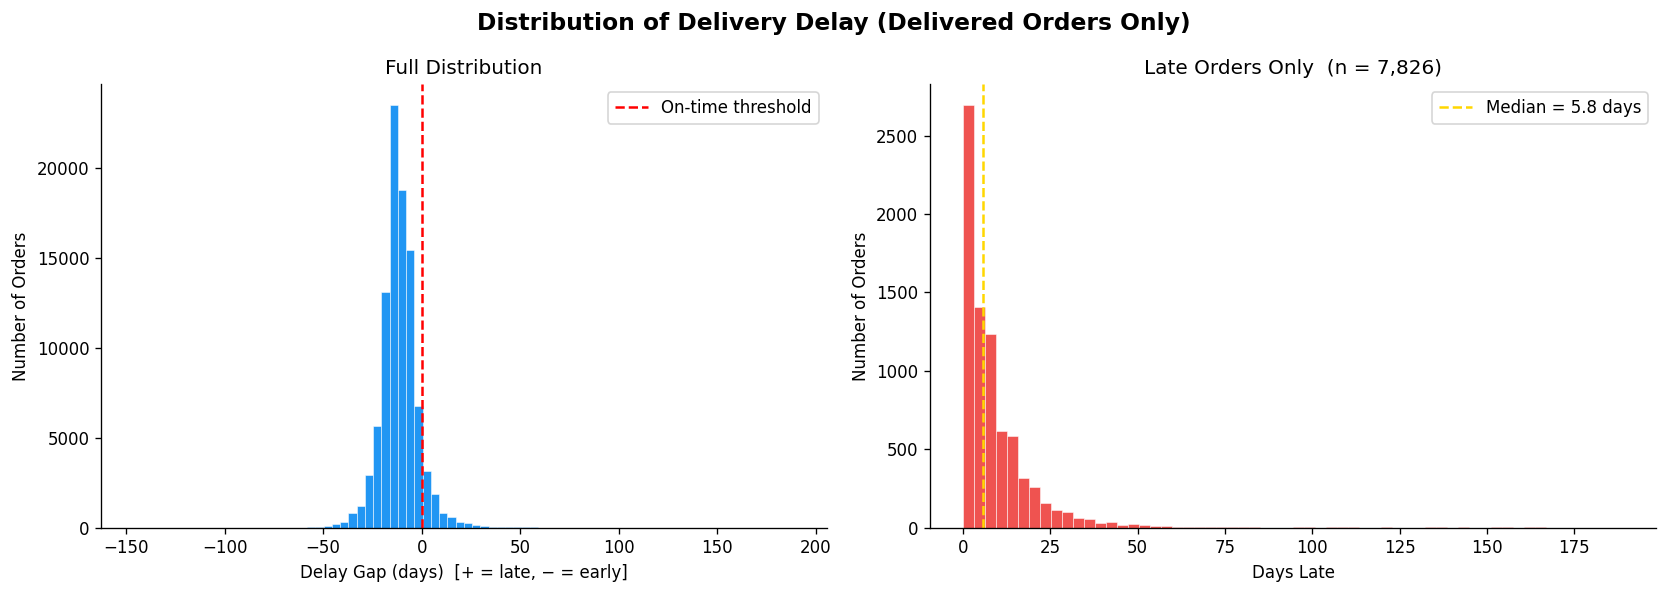


Overall late-delivery rate: 8.1%
Median delay for late orders: 5.8 days
Max delay observed: 189.0 days


In [28]:
delivered = master[master["order_status"] == "delivered"].dropna(subset=["delay_gap"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribution of Delivery Delay (Delivered Orders Only)", fontsize=14, fontweight="bold")

# Left: Full distribution
ax = axes[0]
ax.hist(delivered["delay_gap"], bins=80, color="#2196F3", edgecolor="white", linewidth=0.3)
ax.axvline(0, color="red", linestyle="--", linewidth=1.5, label="On-time threshold")
ax.set_xlabel("Delay Gap (days)  [+ = late, − = early]")
ax.set_ylabel("Number of Orders")
ax.set_title("Full Distribution")
ax.legend()

# Right: Late orders only (delay_gap > 0)
ax = axes[1]
late_only = delivered[delivered["delay_gap"] > 0]["delay_gap"]
ax.hist(late_only, bins=60, color="#EF5350", edgecolor="white", linewidth=0.3)
ax.set_xlabel("Days Late")
ax.set_ylabel("Number of Orders")
ax.set_title(f"Late Orders Only  (n = {len(late_only):,})")
ax.axvline(late_only.median(), color="gold", linestyle="--", linewidth=1.5,
           label=f"Median = {late_only.median():.1f} days")
ax.legend()

plt.tight_layout()
plt.savefig("eda_delay_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

late_rate = (delivered["is_late"] == 1).mean()
print(f"\nOverall late-delivery rate: {late_rate*100:.1f}%")
print(f"Median delay for late orders: {late_only.median():.1f} days")
print(f"Max delay observed: {late_only.max():.1f} days")

### 9.2 Late Delivery Rate by Product Category

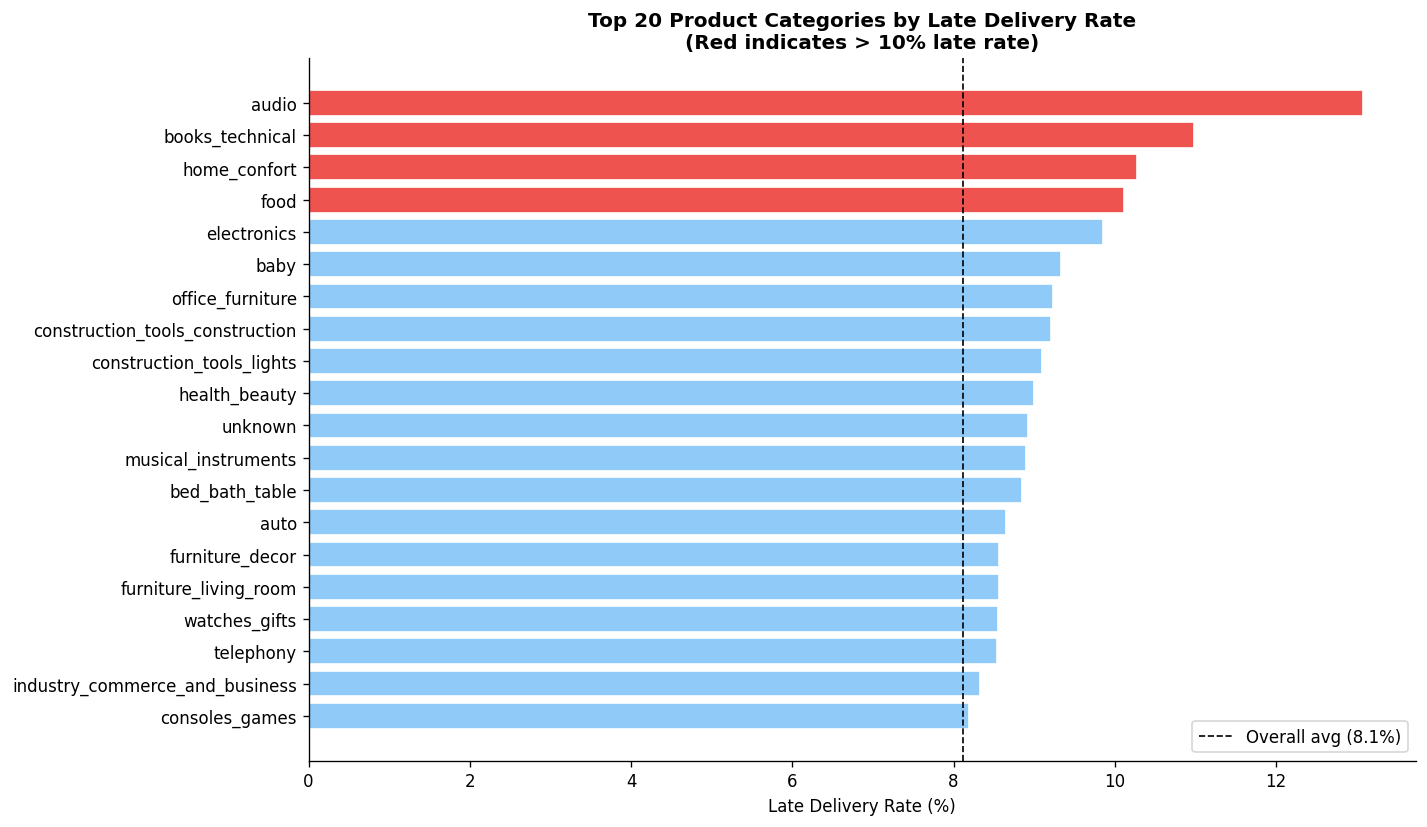

In [31]:
cat_stats = (
    delivered
    .groupby("product_category_name_english")
    .agg(
        n_orders=("order_id",  "count"),
        late_rate=("is_late",  "mean"),
    )
    .reset_index()
    .query("n_orders >= 200")   # only categories with enough data
    .sort_values("late_rate", ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 7))
colors = ["#EF5350" if v > 0.1 else "#90CAF9" for v in cat_stats["late_rate"].head(20)]
bars = ax.barh(cat_stats["product_category_name_english"].head(20),
               cat_stats["late_rate"].head(20) * 100,
               color=colors, edgecolor="white")

ax.set_xlabel("Late Delivery Rate (%)")
ax.set_title("Top 20 Product Categories by Late Delivery Rate\n(Red indicates > 10% late rate)", fontweight="bold")

ax.axvline(late_rate * 100, color="black", linestyle="--", linewidth=1,
           label=f"Overall avg ({late_rate*100:.1f}%)")
ax.invert_yaxis()  # Put highest rate at the top
ax.legend()

plt.tight_layout()
plt.savefig("eda_late_by_category.png", dpi=120, bbox_inches="tight")
plt.show()

### 9.3 Delay vs. Price – Does Order Value Affect Lateness?

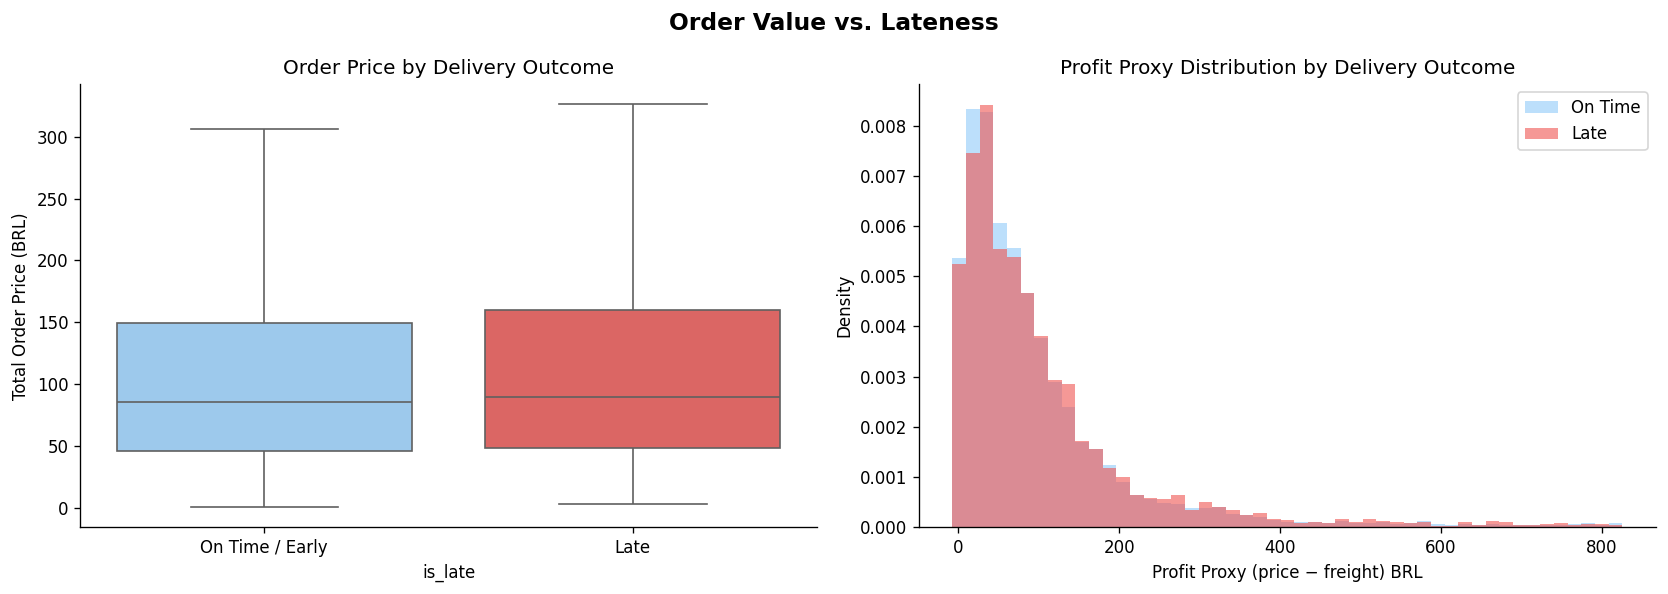

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Order Value vs. Lateness", fontsize=14, fontweight="bold")

# Ensure is_late is treated as a standard integer for the palette mapping
delivered_plot = delivered.copy()
delivered_plot["is_late"] = delivered_plot["is_late"].astype(int)

# Left: Boxplot of price by late/on-time
ax = axes[0]
sns.boxplot(
    data=delivered_plot, x="is_late", y="total_price",
    palette={"0": "#90CAF9", "1": "#EF5350"},  # Keys as strings to match categorical mapping
    ax=ax, showfliers=False,
    order=[0, 1]
)
ax.set_xticklabels(["On Time / Early", "Late"])
ax.set_ylabel("Total Order Price (BRL)")
ax.set_title("Order Price by Delivery Outcome")

# Right: Distribution of profit proxy
ax = axes[1]
bins = np.linspace(delivered_plot["profit_proxy"].quantile(0.01),
                   delivered_plot["profit_proxy"].quantile(0.99), 50)

for label, color, grp in [(0, "#90CAF9", "On Time"), (1, "#EF5350", "Late")]:
    sub = delivered_plot[delivered_plot["is_late"] == label]["profit_proxy"].dropna()
    ax.hist(sub, bins=bins, alpha=0.6, color=color, label=grp, density=True)

ax.set_xlabel("Profit Proxy (price − freight) BRL")
ax.set_ylabel("Density")
ax.set_title("Profit Proxy Distribution by Delivery Outcome")
ax.legend()

plt.tight_layout()
plt.savefig("eda_value_vs_lateness.png", dpi=120, bbox_inches="tight")
plt.show()

### 9.4 Order Volume Over Time

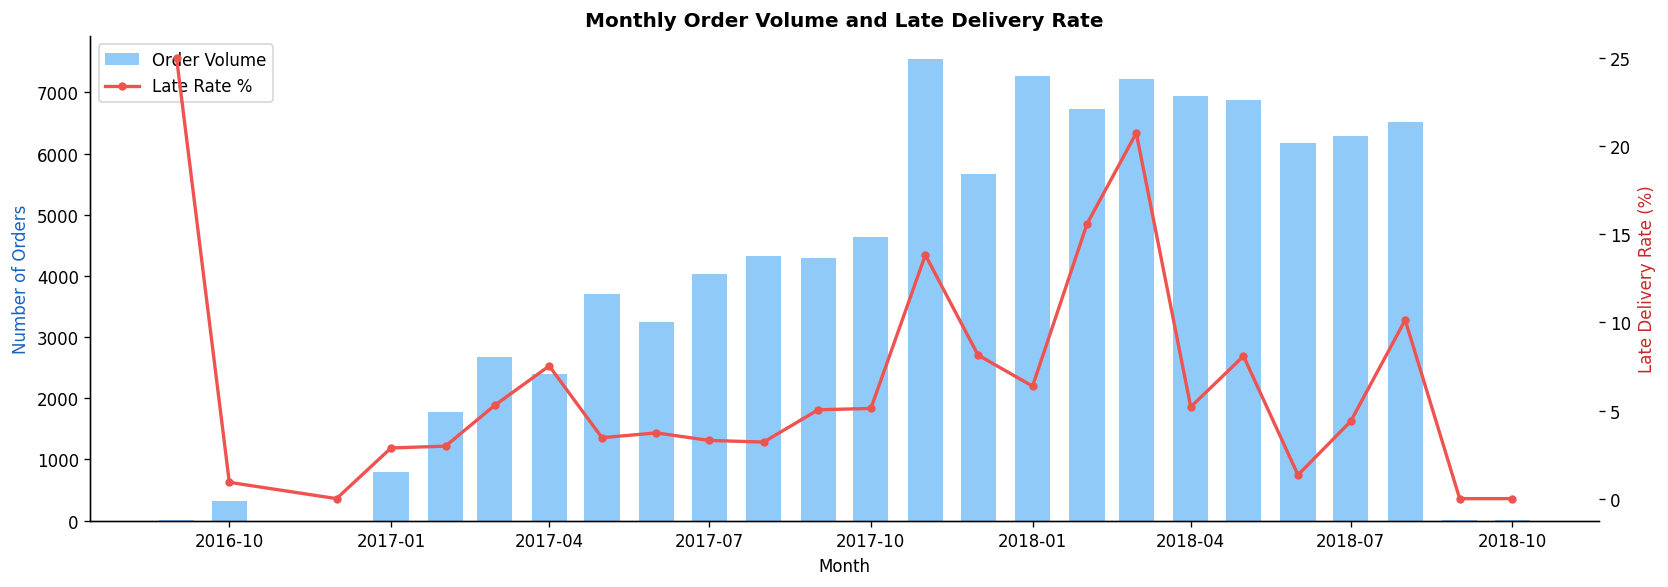

In [35]:
master["order_month"] = master["order_purchase_timestamp"].dt.to_period("M")

monthly = (
    master.groupby("order_month")
    .agg(
        n_orders=("order_id",  "count"),
        late_pct= ("is_late",  lambda x: x.mean() * 100 if x.notna().sum() > 0 else np.nan),
    )
    .reset_index()
)
monthly["order_month_dt"] = monthly["order_month"].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(monthly["order_month_dt"], monthly["n_orders"],
        width=20, color="#90CAF9", label="Order Volume")
ax2.plot(monthly["order_month_dt"], monthly["late_pct"],
         color="#EF5350", linewidth=2, marker="o", markersize=4, label="Late Rate %")

ax1.set_xlabel("Month")
ax1.set_ylabel("Number of Orders", color="#1565C0")
ax2.set_ylabel("Late Delivery Rate (%)", color="#C62828")
ax1.set_title("Monthly Order Volume and Late Delivery Rate", fontweight="bold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.savefig("eda_monthly_volume.png", dpi=120, bbox_inches="tight")
plt.show()

### 9.5 Review Score vs. Delivery Lateness

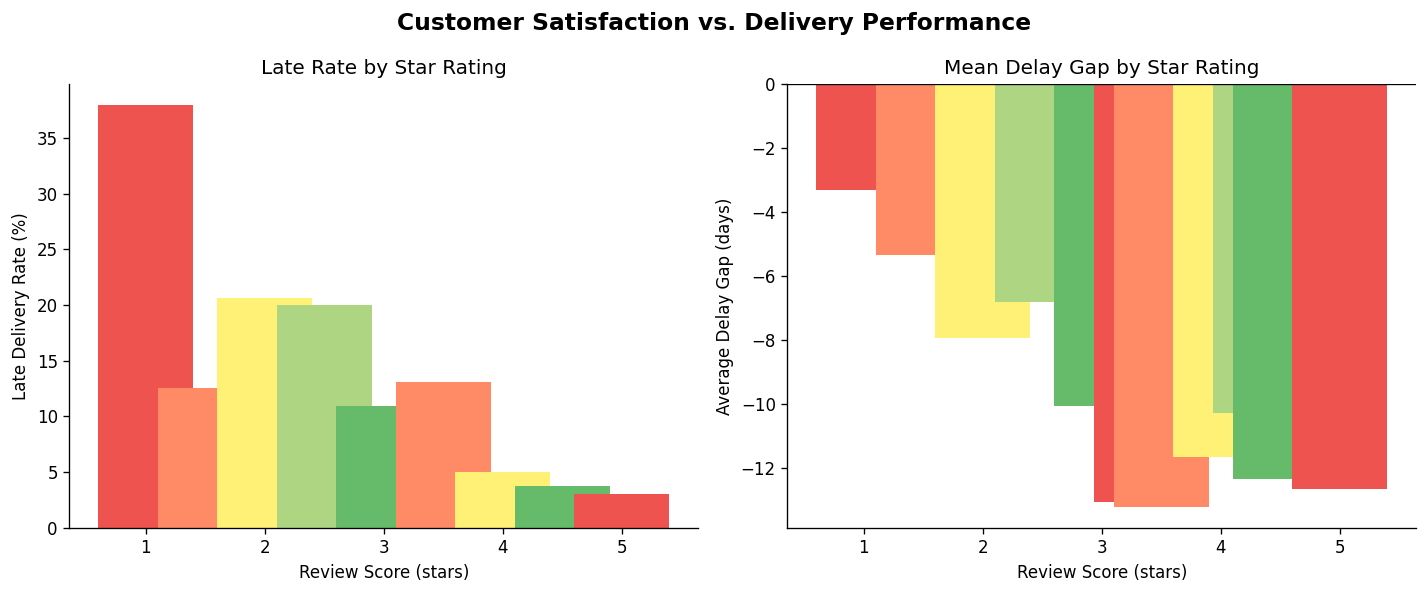


Key finding: As review score drops, the late delivery rate rises sharply.
 review_score     n  late_rate  avg_delay
     1.000000  9312   0.379403  -3.323466
     1.500000     8      0.125  -5.342746
     2.000000  2916   0.206447  -7.938540
     2.500000    30        0.2  -6.819354
     3.000000  7915   0.109665 -10.087321
     3.333333     1        0.0 -13.091065
     3.500000    23   0.130435 -13.220016
     4.000000 18868   0.050085 -11.682696
     4.333333     1        0.0 -10.287153
     4.500000    53   0.037736 -12.358327
     5.000000 56697   0.030002 -12.683029


In [36]:
score_late = (
    delivered[delivered["no_review_flag"] == 0]
    .groupby("review_score")
    .agg(
        n=         ("order_id",  "count"),
        late_rate= ("is_late",   "mean"),
        avg_delay= ("delay_gap", "mean"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Customer Satisfaction vs. Delivery Performance", fontsize=14, fontweight="bold")

ax = axes[0]
ax.bar(score_late["review_score"], score_late["late_rate"] * 100,
       color=["#EF5350","#FF8A65","#FFF176","#AED581","#66BB6A"])
ax.set_xlabel("Review Score (stars)")
ax.set_ylabel("Late Delivery Rate (%)")
ax.set_title("Late Rate by Star Rating")
ax.set_xticks([1,2,3,4,5])

ax = axes[1]
ax.bar(score_late["review_score"], score_late["avg_delay"],
       color=["#EF5350","#FF8A65","#FFF176","#AED581","#66BB6A"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Review Score (stars)")
ax.set_ylabel("Average Delay Gap (days)")
ax.set_title("Mean Delay Gap by Star Rating")
ax.set_xticks([1,2,3,4,5])

plt.tight_layout()
plt.savefig("eda_review_vs_lateness.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nKey finding: As review score drops, the late delivery rate rises sharply.")
print(score_late.to_string(index=False))

## 10. Save the Clean Master DataFrame

We save the master DataFrame to a CSV so it can be loaded directly in the next notebooks
(EDA deep-dive, feature engineering, and modelling) without repeating all cleaning steps.

In [37]:
import os

OUTPUT_PATH = "/mnt/user-data/outputs/"
os.makedirs(OUTPUT_PATH, exist_ok=True)

output_file = OUTPUT_PATH + "olist_master_clean.csv"
master.to_csv(output_file, index=False)

print(f"Master DataFrame saved to: {output_file}")
print(f"Shape: {master.shape}")
print(f"Columns ({master.shape[1]} total):")
for i, col in enumerate(master.columns):
    print(f"  {i+1:>3}. {col}")

Master DataFrame saved to: /mnt/user-data/outputs/olist_master_clean.csv
Shape: (99441, 44)
Columns (44 total):
    1. order_id
    2. customer_id
    3. order_status
    4. order_purchase_timestamp
    5. order_approved_at
    6. order_delivered_carrier_date
    7. order_delivered_customer_date
    8. order_estimated_delivery_date
    9. customer_unique_id
   10. customer_zip_code_prefix
   11. customer_city
   12. customer_state
   13. total_price
   14. total_freight
   15. n_items
   16. product_id
   17. seller_id
   18. product_category_name
   19. product_name_length
   20. product_description_length
   21. product_photos_qty
   22. product_weight_g
   23. product_length_cm
   24. product_height_cm
   25. product_width_cm
   26. product_category_name_english
   27. seller_zip_code_prefix
   28. seller_city
   29. seller_state
   30. total_payment_value
   31. payment_installments
   32. payment_type
   33. n_payment_methods
   34. review_score
   35. has_review_text
   36. custo

## 11. Cleaning Decision Log – Summary

This table documents every significant cleaning decision made in this notebook.
It is part of the portfolio story and should be referenced in the README.

| Table | Issue Found | Decision | Reason |
|---|---|---|---|
| `orders` | 5 datetime columns stored as strings | Parsed to `datetime64` | Enables arithmetic for delay gap calculation |
| `orders` | 2,965 missing `order_delivered_customer_date` | Left as `NaT` | These are genuinely undelivered orders; imputation would be dishonest |
| `customers` | `zip_code_prefix` stored as int | Cast to zero-padded 5-char string | Prevents join key mismatches (e.g., `1310` ≠ `"01310"`) |
| `customers` | City name inconsistencies | Lowercased and stripped | Ensures groupby operations produce consistent groups |
| `order_items` | `price` outliers (max 6,735 BRL) | Capped at 99th percentile | Preserves business signal; avoids model overfitting to extreme values |
| `products` | 610 rows with null category name | Filled with `'unknown'` | Keeps rows in dataset; unknown is honest about the missing info |
| `products` | 2 rows missing physical dimensions | Imputed with column median | Only 2 rows; median is appropriate for continuous shipping features |
| `products` | Typo: `product_name_lenght` | Renamed to `product_name_length` | Data quality hygiene |
| `geolocation` | ~3 split CSV files | Concatenated into one | They are parts of the same table |
| `geolocation` | Many lat/lng per zip prefix | Aggregated to median centroid | One representative point per prefix needed for joining |
| `geolocation` | Coordinates outside Brazil's bbox | Removed | Clear data entry errors; Brazil's bounding box is well-defined |
| `payments` | Multiple rows per order | Aggregated (sum of value, mode of type) | Modelling is at order grain |
| `reviews` | ~42–58% missing comment fields | Created `has_review_text` binary flag | Text is optional; NaN carries meaning (customer did not comment) |
| `master` | Residual geo lat/lng nulls after join | Filled with national median | Zip prefix not found in geo table; median is safe fallback |

### What We Chose NOT to Do
- We did **not** drop late-delivery rows as outliers. Late deliveries are exactly what we are trying to predict — removing them would destroy the signal.
- We did **not** filter to only "delivered" orders during cleaning. That filter happens at modelling time so the cleaning notebook remains general-purpose.
- We did **not** impute the `order_delivered_customer_date` — doing so would fabricate our target variable.

### Assumptions Logged
1. A `profit_proxy = price − freight` is a reasonable stand-in for true margin until financial data is available.
2. Orders with `order_status != 'delivered'` will be excluded from the regression/classification model but kept in the master file for potential future work.
3. When an order has multiple items from different sellers, we attribute the order to the seller of the **first** item for geo features. This is a simplification that can be revisited.